# Object Detection with YOLO and Faster R-CNN

This notebook trains and evaluates two object-detection models on the African Wildlife dataset.

- **YOLO** uses the dataset directly because the labels are already in YOLO format.
- **Faster R-CNN** uses the same labels, but the bounding boxes are converted from YOLO format to absolute `x_min, y_min, x_max, y_max` coordinates.

The comments are written to help students understand the purpose of each step.


In [10]:
# Standard library imports
from pathlib import Path
import random
import glob
import zipfile
import urllib.request
import yaml

# Image processing and visualization
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from IPython.display import display
from PIL import Image as PILImage

# PyTorch and Torchvision
import torch
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Ultralytics YOLO
from ultralytics import YOLO


In [11]:
# Use the GPU if CUDA is available; otherwise fall back to the CPU.
# On a local laptop without a CUDA-capable GPU, training will still work but will be slower.
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)


Device: cuda


In [12]:
# Download location for the dataset.
# The dataset will be stored in a local folder called "datasets".
DATA_ROOT = Path("datasets")
DATA_ROOT.mkdir(exist_ok=True)

# Ultralytics African Wildlife dataset ZIP file.
zip_url = "https://github.com/ultralytics/assets/releases/download/v0.0.0/african-wildlife.zip"
zip_path = DATA_ROOT / "african-wildlife.zip"

# Download the ZIP file only if it does not already exist.
if not zip_path.exists():
    print("Starting download...")
    urllib.request.urlretrieve(zip_url, zip_path)
    print("Download finished.")
else:
    print("ZIP file already exists.")


ZIP file already exists.


In [13]:
# Folder where the dataset will be extracted.
dataset_dir = DATA_ROOT / "african-wildlife"

# Extract the dataset only if the folder does not already exist.
if not dataset_dir.exists():
    dataset_dir.mkdir(exist_ok=True)
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("Extraction finished.")
else:
    print("Dataset is already extracted.")


Dataset is already extracted.


In [14]:
# Quick check: print the dataset folder and all subfolders.
# This helps us verify that images/, labels/, train/, val/, and test/ exist.
print("Dataset folder:", dataset_dir)
print("Exists:", dataset_dir.exists())

for p in dataset_dir.rglob("*"):
    if p.is_dir():
        print(p)


Dataset folder: datasets\african-wildlife
Exists: True
datasets\african-wildlife\images
datasets\african-wildlife\labels
datasets\african-wildlife\images\test
datasets\african-wildlife\images\train
datasets\african-wildlife\images\val
datasets\african-wildlife\labels\test
datasets\african-wildlife\labels\train
datasets\african-wildlife\labels\val


In [15]:
# Read the existing dataset YAML file.
# The YAML file contains the paths to train/val/test and the class names.
yaml_path = dataset_dir / "african-wildlife.yaml"

with open(yaml_path, "r", encoding="utf-8") as f:
    data_config = yaml.safe_load(f)

# The class names can be stored either as a dictionary or as a list.
# In this dataset, they are usually stored as:
# {0: "buffalo", 1: "elephant", 2: "rhino", 3: "zebra"}
names = data_config["names"]

if isinstance(names, dict):
    class_names = [names[i] for i in sorted(names.keys())]
elif isinstance(names, list):
    class_names = names
else:
    raise ValueError("Unknown class-name format in the YAML file.")

print("Classes:", class_names)


Classes: ['buffalo', 'elephant', 'rhino', 'zebra']


In [16]:
# Number of real object classes in the dataset.
num_detection_classes = len(class_names)

# Faster R-CNN reserves class index 0 for the background class.
# Therefore, the model needs one additional class.
num_rcnn_classes = len(class_names) + 1

print("Detection classes:", num_detection_classes)
print("Faster R-CNN classes including background:", num_rcnn_classes)


Detection classes: 4
Faster R-CNN classes including background: 5


# YOLO Training

YOLO can use the dataset directly because the labels are already stored in YOLO format:

```text
class_id x_center y_center width height
```

The coordinates are normalized between 0 and 1. Ultralytics YOLO already applies its own training augmentations, so we do not add custom augmentations here.


In [17]:
# Load a small pretrained YOLO model.
# yolov8n.pt is the "nano" version: small, fast, and suitable for beginner experiments.
yolo_model = YOLO("yolov8n.pt")

# Train YOLO on the African Wildlife dataset.
# Adjust the data path if your dataset is stored somewhere else.
yolo_results = yolo_model.train(
    data="C:\\Users\\chris\\Documents\\GitHub\\ML_DL\\Datasets\\african-wildlife\\african-wildlife.yaml",
    epochs=30,
    imgsz=256,
    batch=8,
    name="african_wildlife_yolo",
    project="C:\\Users\\chris\\Documents\\GitHub\\ML_DL\\runs_yolo",
    exist_ok=True,
)


Ultralytics 8.4.46  Python-3.14.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\chris\Documents\GitHub\ML_DL\Datasets\african-wildlife\african-wildlife.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=african_wildlife_yolo, nbs=64, nms=F

In [18]:
# Validate the YOLO model.
# By default, model.val() evaluates on the validation split defined in the YAML file.
yolo_metrics = yolo_model.val()
print(yolo_metrics)


Ultralytics 8.4.46  Python-3.14.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3070, 8192MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 850.6788.0 MB/s, size: 101.8 KB)
val: Scanning C:\Users\chris\Documents\GitHub\datasets\african-wildlife\labels\val.cache... 225 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 225/225 94.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 4.1it/s 3.7s<0.2s
                   all        225        379      0.926      0.872      0.926      0.743
               buffalo         62         89      0.975      0.864      0.948      0.777
              elephant         53         91      0.861      0.818      0.891      0.701
                 rhino         55         85      0.944      0.929      0.944      0.779
                 zebra         59        114      0.923      0.877      0.921      0.

# Faster R-CNN Training

Faster R-CNN cannot use YOLO labels directly. It expects bounding boxes in pixel coordinates and it reserves class `0` for the background.

Therefore, this section converts labels from:

```text
YOLO: class_id x_center y_center width height
```

to:

```text
Faster R-CNN: label, x_min, y_min, x_max, y_max
```

where the label is shifted by `+1` because `0` means background for Faster R-CNN.


In [19]:
def yolo_to_xyxy(x_center, y_center, width, height, img_width, img_height):
    """
    Convert a bounding box from YOLO format to Faster R-CNN format.

    YOLO format:
        x_center, y_center, width, height
        All values are normalized between 0 and 1.

    Faster R-CNN format:
        x_min, y_min, x_max, y_max
        Values are absolute pixel coordinates.
    """

    x_center = x_center * img_width
    y_center = y_center * img_height
    width = width * img_width
    height = height * img_height

    x_min = x_center - width / 2
    y_min = y_center - height / 2
    x_max = x_center + width / 2
    y_max = y_center + height / 2

    return [x_min, y_min, x_max, y_max]


In [20]:
class DetectionAugmentation:
    """
    Simple augmentation pipeline for Faster R-CNN.

    Important: For object detection, every geometric transformation applied to
    the image must also be applied to the bounding boxes. This class handles:

    1. Resizing images to a fixed square size
    2. Updating bounding boxes after resizing
    3. Random horizontal flipping during training
    4. Light brightness and contrast changes during training
    """

    def __init__(self, train=True, image_size=640):
        self.train = train
        self.image_size = image_size

    def __call__(self, image, target):
        # Convert PIL image to PyTorch tensor in C x H x W format.
        image = F.to_tensor(image)

        # Store original image size before resizing.
        _, old_h, old_w = image.shape

        # Resize image to a fixed square size.
        image = F.resize(image, [self.image_size, self.image_size])

        new_h = self.image_size
        new_w = self.image_size

        boxes = target["boxes"].clone()

        # Update bounding box coordinates after resizing.
        if boxes.shape[0] > 0:
            scale_x = new_w / old_w
            scale_y = new_h / old_h

            boxes[:, [0, 2]] *= scale_x
            boxes[:, [1, 3]] *= scale_y

        target["boxes"] = boxes

        if self.train:
            # Random horizontal flip.
            # If the image is flipped, x-coordinates of the boxes must be flipped too.
            if random.random() < 0.5:
                image = F.hflip(image)

                if boxes.shape[0] > 0:
                    x_min = boxes[:, 0].clone()
                    x_max = boxes[:, 2].clone()

                    boxes[:, 0] = new_w - x_max
                    boxes[:, 2] = new_w - x_min

                    target["boxes"] = boxes

            # Random brightness adjustment.
            if random.random() < 0.5:
                image = F.adjust_brightness(
                    image,
                    brightness_factor=random.uniform(0.8, 1.2)
                )

            # Random contrast adjustment.
            if random.random() < 0.5:
                image = F.adjust_contrast(
                    image,
                    contrast_factor=random.uniform(0.8, 1.2)
                )

        return image, target


In [21]:
class WildlifeDetectionDataset(Dataset):
    """
    Custom PyTorch Dataset for Faster R-CNN.

    The dataset is stored in YOLO format, but Faster R-CNN expects a different
    target format. This class performs the conversion while loading each image.

    YOLO label format per line:
        class_id x_center y_center width height

    Faster R-CNN target format:
        {
            "boxes":  Tensor[N, 4] with x_min, y_min, x_max, y_max,
            "labels": Tensor[N], class labels where 0 is background,
            "area":   Tensor[N], box areas,
            "iscrowd": Tensor[N]
        }
    """

    def __init__(self, root_dir, split="train", transforms=None):
        self.root_dir = Path(root_dir)
        self.split = split
        self.transforms = transforms

        self.images_dir = self.root_dir / "images" / split
        self.labels_dir = self.root_dir / "labels" / split

        self.image_paths = sorted(
            list(self.images_dir.glob("*.jpg")) +
            list(self.images_dir.glob("*.jpeg")) +
            list(self.images_dir.glob("*.png"))
        )

        print(f"{split}: {len(self.image_paths)} images found")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]

        # Load image as RGB.
        image = Image.open(img_path).convert("RGB")
        img_width, img_height = image.size

        # YOLO label file has the same file stem as the image.
        label_path = self.labels_dir / f"{img_path.stem}.txt"

        boxes = []
        labels = []

        if label_path.exists():
            with open(label_path, "r") as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()

                # Each YOLO line should contain exactly 5 values.
                if len(parts) != 5:
                    continue

                class_id = int(parts[0])
                x_center, y_center, box_w, box_h = map(float, parts[1:])

                # Convert normalized YOLO coordinates to absolute xyxy coordinates.
                box = yolo_to_xyxy(
                    x_center,
                    y_center,
                    box_w,
                    box_h,
                    img_width,
                    img_height
                )

                boxes.append(box)

                # YOLO class IDs start at 0.
                # Faster R-CNN uses 0 as the background class.
                # Therefore, all real object classes are shifted by +1.
                labels.append(class_id + 1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        # Remove invalid boxes, if any.
        # A valid box must have positive width and height.
        if boxes.shape[0] > 0:
            valid = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
            boxes = boxes[valid]
            labels = labels[valid]

        if boxes.shape[0] > 0:
            area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        else:
            area = torch.as_tensor([], dtype=torch.float32)

        # This dataset does not use COCO-style crowd annotations.
        iscrowd = torch.zeros((boxes.shape[0],), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": iscrowd
        }

        # Apply optional image and box transformations.
        if self.transforms is not None:
            image, target = self.transforms(image, target)
        else:
            image = F.to_tensor(image)

        return image, target


In [22]:
def collate_fn(batch):
    """
    Custom collate function for object detection.

    Each image can contain a different number of objects. The default PyTorch
    collate function tries to stack everything into one tensor, which does not
    work for variable-length targets. This function keeps images and targets as
    tuples of lists.
    """
    return tuple(zip(*batch))


In [23]:
# Create training and validation datasets for Faster R-CNN.
# Training uses augmentation. Validation only resizes the images.
train_dataset = WildlifeDetectionDataset(
    root_dir=dataset_dir,
    split="train",
    transforms=DetectionAugmentation(train=True, image_size=640)
)

val_dataset = WildlifeDetectionDataset(
    root_dir=dataset_dir,
    split="val",
    transforms=DetectionAugmentation(train=False, image_size=640)
)


train: 1052 images found
val: 225 images found


In [24]:
# DataLoaders for Faster R-CNN.
# batch_size=2 is a safe starting point for limited GPU memory.
# num_workers=0 is more stable on Windows and in Jupyter notebooks.
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)


In [25]:
# Load a pretrained Faster R-CNN model with a ResNet50-FPN backbone.
# The model was pretrained on COCO, so we replace only the final prediction head.
rcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

# Get the number of input features for the original classification head.
in_features = rcnn_model.roi_heads.box_predictor.cls_score.in_features

# Replace the original COCO prediction head with a new one for our classes.
# num_rcnn_classes includes the background class.
rcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_rcnn_classes)


In [26]:
# Move the model to the selected device.
# This is important: model and input tensors must be on the same device.
rcnn_model = rcnn_model.to(device)

print("Model device:", next(rcnn_model.parameters()).device)


Model device: cuda:0


In [27]:
# Optimizer and learning-rate scheduler for Faster R-CNN.
# We train only parameters that require gradients.
params = [p for p in rcnn_model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# Reduce the learning rate every 3 epochs.
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)


In [28]:
# Training loop for Faster R-CNN.
# For a first test, one epoch is enough to check whether the pipeline works.
# Increase num_epochs later for better results.
num_epochs = 1

for epoch in range(num_epochs):
    rcnn_model.train()

    epoch_loss = 0.0

    for batch_idx, (images, targets) in enumerate(train_loader):
        # Move images to GPU/CPU.
        images = [img.to(device) for img in images]

        # Move every tensor inside every target dictionary to GPU/CPU.
        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        # In training mode, Faster R-CNN returns a dictionary of losses.
        loss_dict = rcnn_model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backpropagation.
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

        if batch_idx % 20 == 0:
            print(
                f"Epoch [{epoch + 1}/{num_epochs}] "
                f"Batch [{batch_idx}/{len(train_loader)}] "
                f"Loss: {losses.item():.4f}"
            )

    lr_scheduler.step()

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch + 1} finished. Average loss: {avg_loss:.4f}")


Epoch [1/1] Batch [0/526] Loss: 1.8615
Epoch [1/1] Batch [20/526] Loss: 0.2028
Epoch [1/1] Batch [40/526] Loss: 0.2069
Epoch [1/1] Batch [60/526] Loss: 0.1329
Epoch [1/1] Batch [80/526] Loss: 0.2640
Epoch [1/1] Batch [100/526] Loss: 0.2819
Epoch [1/1] Batch [120/526] Loss: 0.2249
Epoch [1/1] Batch [140/526] Loss: 0.4210
Epoch [1/1] Batch [160/526] Loss: 0.3513
Epoch [1/1] Batch [180/526] Loss: 0.1762
Epoch [1/1] Batch [200/526] Loss: 0.1263
Epoch [1/1] Batch [220/526] Loss: 0.1541
Epoch [1/1] Batch [240/526] Loss: 0.2620
Epoch [1/1] Batch [260/526] Loss: 0.1109
Epoch [1/1] Batch [280/526] Loss: 0.2442
Epoch [1/1] Batch [300/526] Loss: 0.1312
Epoch [1/1] Batch [320/526] Loss: 0.0908
Epoch [1/1] Batch [340/526] Loss: 0.1298
Epoch [1/1] Batch [360/526] Loss: 0.1879
Epoch [1/1] Batch [380/526] Loss: 0.3543
Epoch [1/1] Batch [400/526] Loss: 0.4439
Epoch [1/1] Batch [420/526] Loss: 0.1131
Epoch [1/1] Batch [440/526] Loss: 0.5679
Epoch [1/1] Batch [460/526] Loss: 0.1033
Epoch [1/1] Batch [480

In [29]:
def show_rcnn_prediction(image_tensor, prediction, class_names, score_threshold=0.5):
    """
    Display Faster R-CNN predictions directly inside the notebook.

    Parameters
    ----------
    image_tensor:
        Image tensor in C x H x W format with values between 0 and 1.

    prediction:
        Output of rcnn_model([image])[0]. It contains predicted boxes,
        labels, and confidence scores.

    class_names:
        List of class names without the background class.

    score_threshold:
        Only predictions with a confidence score above this threshold are drawn.
    """

    # Convert tensor image from C,H,W to H,W,C and scale to 0-255.
    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    image = (image * 255).astype(np.uint8).copy()

    boxes = prediction["boxes"].detach().cpu().numpy()
    labels = prediction["labels"].detach().cpu().numpy()
    scores = prediction["scores"].detach().cpu().numpy()

    print("Total predictions:", len(boxes))

    shown = 0

    for box, label, score in zip(boxes, labels, scores):
        # Skip low-confidence predictions.
        if score < score_threshold:
            continue

        x_min, y_min, x_max, y_max = box.astype(int)

        # Faster R-CNN label 0 is background.
        # Real class labels start at 1, so we subtract 1 for class_names.
        class_name = class_names[label - 1]

        cv2.rectangle(
            image,
            (x_min, y_min),
            (x_max, y_max),
            (255, 0, 0),
            3
        )

        cv2.putText(
            image,
            f"{class_name}: {score:.2f}",
            (x_min, max(y_min - 10, 25)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 0, 0),
            2
        )

        shown += 1

    print("Displayed predictions:", shown)

    # Display the annotated image directly in the notebook.
    display(PILImage.fromarray(image))


Total predictions: 2
Displayed predictions: 1


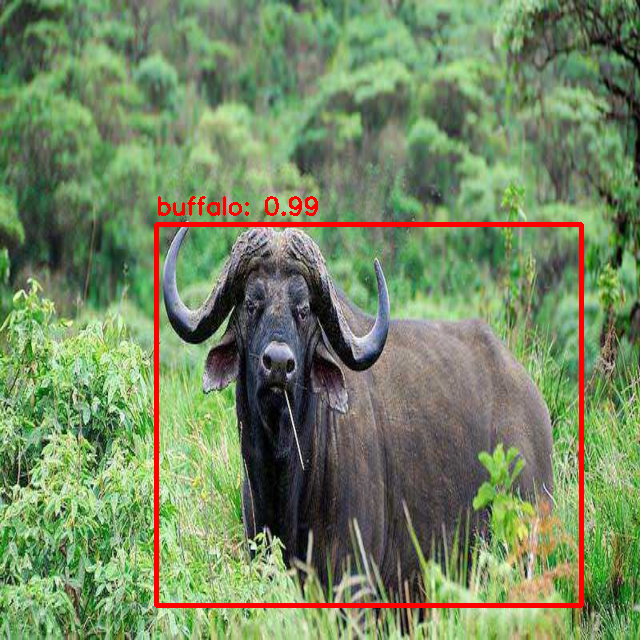

In [30]:
# Run inference on one validation image and display the prediction.
rcnn_model.eval()

image, target = val_dataset[0]

with torch.no_grad():
    prediction = rcnn_model([image.to(device)])[0]

show_rcnn_prediction(
    image_tensor=image,
    prediction=prediction,
    class_names=class_names,
    score_threshold=0.25
)
